# FCIdump: Integrating Psi4 into PySCF in a Reproducable Way

In [1]:
import numpy as np
import psi4 
import os
import pyscf
from pyscf import ao2mo, tools, gto, scf
import pyscf.mcscf
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Generate a Psi4 Molecule and run FCIdump

In [15]:
xyz_path

'/Users/grierjones/DDLUCJ/check_fcidump/ddcc_mol/formaldehyde100.xyz'

In [2]:
molecules = ['water', 'ammonia', 'methane', 'formaldehyde', 'ethane', 'methanol', 'ethelyne']
num = ['10','100']
molecule = molecules[3] + num[1]
xyz_path = os.path.join(os.path.expanduser("~"), "DDLUCJ", "check_fcidump", "ddcc_mol", molecule + ".xyz")

with open(xyz_path, 'r') as f:
    xyz_text = f.read()



In [16]:
help(psi4.geometry)

Help on function geometry in module psi4.driver.molutil:

geometry(geom: str, name: str = 'default') -> psi4.core.Molecule
    Function to create a molecule object of name *name* from the
    geometry in string *geom*. Permitted for user use but deprecated
    in driver in favor of explicit molecule-passing. Comments within
    the string are filtered.



In [3]:
mol = psi4.geometry(xyz_text)

psi4.core.clean()
psi4.core.be_quiet()

psi4.set_options({
    'basis': 'STO-3G',
    # 'scf_type': 'pk',
    'reference': 'rhf',
    'e_convergence': 1e-8,
    'd_convergence': 1e-8,
    'print_mos': True,
    'frozen_DOCC': [0]
})

rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
# FCIDUMP
psi4.driver.p4util.fcidump(scf_wfn, fname= molecule + "_INTDUMP", oe_ints=['EIGENVALUES'])

In [4]:
def clean_xyz_string(xyz_text):
    lines = xyz_text.splitlines()
    return '\n'.join(line for line in lines if not line.lower().startswith(('units', 'symmetry')))

# Step 2: Generate Same molecule in PySCF, and save for future use

In [5]:
# Specify molecule properties
open_shell = False
spin_sq = 0
 
# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=clean_xyz_string(xyz_text),
    basis="STO-3G",
    symmetry="c1",
)
 
# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())
 
# Get molecular integrals
scf_ = pyscf.scf.RHF(mol).run()
num_orbitals = len(active_space)
n_electrons = int(sum(scf_.mo_occ[active_space]))
num_elec_a = (n_electrons + mol.spin) // 2
num_elec_b = (n_electrons - mol.spin) // 2
cas = pyscf.mcscf.CASCI(scf_, num_orbitals, (num_elec_a, num_elec_b))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)

converged SCF energy = -112.353625689729


# Step 3: Reformat FCIdump files and run PySCF from FCIdump

In [6]:
def fix_fcidump_header(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Identify header lines between &FCI and &END
    header_start = None
    header_end = None
    for i, line in enumerate(lines):
        if '&FCI' in line:
            header_start = i
        if '&END' in line:
            header_end = i
            break

    if header_start is None or header_end is None:
        raise ValueError("Could not find a valid &FCI ... &END block")

    # Join and sanitize header
    header_lines = lines[header_start:header_end+1]
    header_joined = ' '.join(line.strip() for line in header_lines)
    header_joined = header_joined.replace('\n', '').replace('  ', ' ').replace(' ,', ',')

    # Replace old header with single-line version
    new_lines = lines[:header_start] + [header_joined + '\n'] + lines[header_end+1:]

    # Write back to file
    with open(filename, 'w', encoding='utf-8') as f:
        f.writelines(new_lines)

    print(f"[OK] Fixed header in {filename}")


In [7]:
fix_fcidump_header(molecule+'_INTDUMP')

[OK] Fixed header in formaldehyde100_INTDUMP


In [8]:
from pyscf import gto, scf

mol_fcidump = gto.Mole()
mol_fcidump.build()
# mol_fcidump.build(
#     atom=clean_xyz_string(xyz_text),
#     basis="STO-3G",
#     symmetry="c1",
# )
scf_fcidump = scf.RHF(mol_fcidump).from_fcidump(molecule + '_INTDUMP', molpro_orbsym=False).run()
# scf_fcidump.kernel()


Parsing formaldehyde100_INTDUMP
converged SCF energy = -112.353625689706


Overwritten attributes  get_ovlp get_hcore  of <class 'pyscf.scf.hf.RHF'>
/Users/grierjones/miniconda3/envs/psi4/lib/python3.10/site-packages/pyscf/gto/mole.py:1293: UserWarning: Function mol.dumps drops attribute energy_nuc because it is not JSON-serializable
  warnings.warn(msg)
/Users/grierjones/miniconda3/envs/psi4/lib/python3.10/site-packages/pyscf/gto/mole.py:1293: UserWarning: Function mol.dumps drops attribute intor_symmetric because it is not JSON-serializable
  warnings.warn(msg)


# Step 4: Check Difference Between Mol obhjects

In [9]:
num_orbitals_psi4 = scf_fcidump.mo_coeff.shape[0]
mo_occ_psi4 = scf_fcidump.mo_occ

n_electrons_psi4 = int(sum(mo_occ_psi4[active_space]))
num_elec_a_psi4 = (n_electrons_psi4 + mol_fcidump.spin) // 2
num_elec_b_psi4 = (n_electrons_psi4 - mol_fcidump.spin) // 2

cas_psi4 = pyscf.mcscf.CASCI(scf_fcidump, num_orbitals_psi4, (num_elec_a_psi4, num_elec_b_psi4))
mo_psi4 = cas_psi4.sort_mo(active_space, base=0)
hcore_psi4, nuclear_repulsion_energy_psi4 = cas_psi4.get_h1cas(mo_psi4)
eri_psi4 = ao2mo.restore(1, cas_psi4.get_h2cas(mo_psi4), num_orbitals_psi4)

In [10]:
df = pd.DataFrame(columns=['Diff Number of Orbitals', 'Diff Number of Electrons',
                           'Diff MO Coefficients', 'One Electron', 
                           "Nuclear Repulsion", "Two Electron"])


In [11]:
df.loc[len(df)] = [num_orbitals_psi4 - num_orbitals, n_electrons_psi4 - n_electrons, mo_psi4 - mo, np.allclose(hcore_psi4,hcore), nuclear_repulsion_energy_psi4 - nuclear_repulsion_energy,np.allclose(eri_psi4, eri) ]

In [12]:
df

,Diff Number of Orbitals,Diff Number of Electrons,Diff MO Coefficients,One Electron,Nuclear Repulsion,Two Electron
0,0,0,"[[0.005677866556316746, -0.0001717296914508433...",False,-1.456898e-08,False


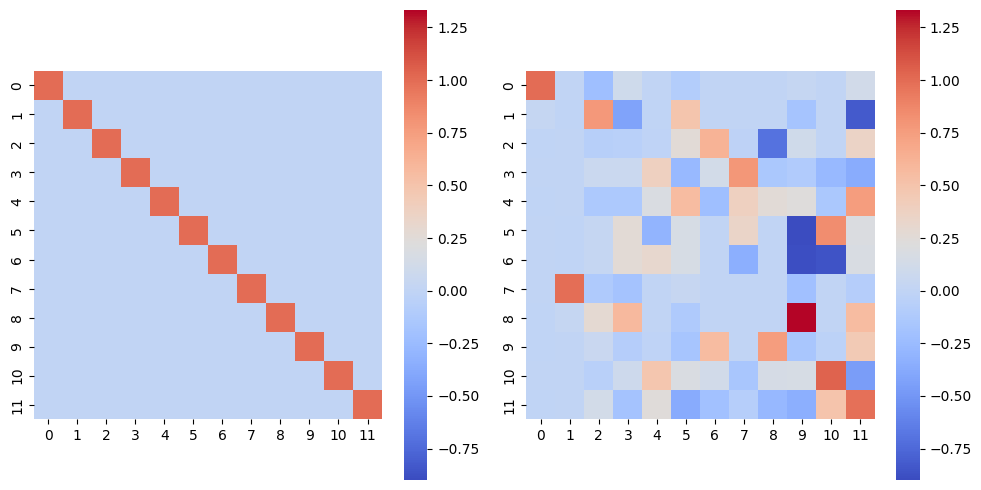

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute global vmin and vmax
vmin = min(np.min(scf_fcidump.mo_coeff), np.min(scf_.mo_coeff))
vmax = max(np.max(scf_fcidump.mo_coeff), np.max(scf_.mo_coeff))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.heatmap(scf_fcidump.mo_coeff, ax=ax1, square=True, vmin=vmin, vmax=vmax, cmap='coolwarm')
sns.heatmap(scf_.mo_coeff, ax=ax2, square=True, vmin=vmin, vmax=vmax, cmap='coolwarm')

plt.tight_layout()
plt.show()


In [ ]:
np.isclose(hcore_psi4,hcore).all()

# Check FCIdump from PySCF file

In [ ]:
pyscf.__version__

In [ ]:
np.diag(mo_psi4)

In [ ]:
np.diag(mo)

In [ ]:
np.isclose(mo_psi4, mo)

In [ ]:
mo

In [ ]:
mo_psi4

In [ ]:
np.isclose(mo,scf_wfn.Ca().np, atol=1e-3)

In [ ]:
scf_wfn.Ca().np

In [ ]:
np.isclose(hcore_psi4,hcore)

In [ ]:
np.isclose(eri_psi4,eri)